# Notebook 04 — Modelagem e Métricas

Este notebook treina os 8 modelos de clusterização.

## Bibliotecas

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import time
import joblib
os.environ['OMP_NUM_THREADS'] = '9'
from IPython.display import display
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

## Carregamento dos dados

In [2]:
df_model = pd.read_parquet('../data/data_features.parquet')
df_bis = pd.read_parquet('../data/data_cleaned_with_ids.parquet')

print(f"Features para modelagem: {df_model.shape}")
print(f"Dados originais com IDs: {df_bis.shape}")

Features para modelagem: (2214, 10)
Dados originais com IDs: (2214, 13)


## Preparação dos datasets

- Dataset 1: Com todas as features
- Dataset 2: Sem a feature Comprimento (validação de hipótese de similaridade com diâmetro)

In [3]:
# Dataset 1: COM a coluna de comprimento
dados_para_modelo_completo = df_model

# Dataset 2: SEM a coluna de comprimento
coluna_para_remover = 'qt_comprimento_material_boxcox'
dados_para_modelo_sem_comp = df_model.drop(columns=[coluna_para_remover])

print(f"Dataset completo: {dados_para_modelo_completo.shape}")
print(f"Dataset sem comprimento: {dados_para_modelo_sem_comp.shape}")

Dataset completo: (2214, 10)
Dataset sem comprimento: (2214, 9)


## Funções auxiliares

In [4]:
def get_stats_por_cluster(df, coluna_de_grupo, colunas_de_features):
    """Retorna estatísticas descritivas agrupadas por cluster."""
    return df.groupby(coluna_de_grupo)[colunas_de_features].agg(['mean', 'std', 'min', 'max'])


def salvar_artefatos(nome_experimento, modelo, dados, clusters, df_original, 
                     colunas_perfil, nome_coluna_cluster, k, tipo_modelo,
                     score_sil, score_db, dist_cofenetica=None):
    """Salva todos os artefatos de um experimento em sua subpasta."""
    
    pasta = f'../models/{nome_experimento}'
    os.makedirs(pasta, exist_ok=True)
    
    # 1. Salvar modelo
    joblib.dump(modelo, f'{pasta}/modelo.pkl')
    
    # 2. Salvar métricas
    metricas = {
        'modelo': tipo_modelo,
        'k': k,
        'silhouette_score': round(score_sil, 4),
        'davies_bouldin_score': round(score_db, 4),
    }
    if dist_cofenetica is not None:
        metricas['correlacao_cofenetica'] = round(dist_cofenetica, 4)
    
    with open(f'{pasta}/metricas.json', 'w', encoding='utf-8') as f:
        json.dump(metricas, f, indent=2, ensure_ascii=False)
    
    # 3. PCA + gráfico
    pca = PCA(n_components=2, random_state=42)
    dados_pca = pca.fit_transform(dados)
    df_pca = pd.DataFrame(data=dados_pca, columns=['PC1', 'PC2'])
    df_pca['cluster'] = clusters
    
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='viridis', legend=None)
    plt.title(f'Clusters — {nome_experimento} (K={k})', fontsize=16)
    plt.savefig(f'{pasta}/pca_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 4. Gráfico SKUs por cluster
    df_original[nome_coluna_cluster] = clusters
    
    plt.figure(figsize=(20, 8))
    ax = sns.countplot(data=df_original, x=nome_coluna_cluster,
                       order=df_original[nome_coluna_cluster].value_counts().index)
    ax.bar_label(ax.containers[0])
    plt.title(f'Número de SKUs por Cluster — {nome_experimento} (K={k})', fontsize=16)
    plt.xlabel('Cluster')
    plt.ylabel('Quantidade de SKUs')
    plt.xticks(rotation=90)
    plt.savefig(f'{pasta}/skus_por_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 5. Perfil estatístico
    tabela_stats = get_stats_por_cluster(
        df=df_original,
        coluna_de_grupo=nome_coluna_cluster,
        colunas_de_features=colunas_perfil
    )
    tabela_stats.to_csv(f'{pasta}/perfil_estatistico.csv')
    display(tabela_stats)
    
    # Exibir métricas
    print(f"\n{'='*60}")
    print(f"  Experimento: {nome_experimento}")
    print(f"  - Pontuação de Silhueta:     {score_sil:.4f} (Maior é melhor)")
    print(f"  - Índice de Davies-Bouldin:  {score_db:.4f} (Menor é melhor)")
    if dist_cofenetica is not None:
        print(f"  - Correlação Cofenética:     {dist_cofenetica:.4f} (Maior é melhor)")
    print(f"  ✓ Artefatos salvos em: {pasta}/")
    print(f"{'='*60}")

In [5]:
# Colunas para perfil estatístico
colunas_perfil_comp = ["qt_altura_material", "diametro_material", "qt_comprimento_material", "qt_peso_bruto"]
colunas_perfil_sem_comp = ["qt_altura_material", "diametro_material", "qt_peso_bruto"]

---
## Experimento 1 — Hierárquico Ward K=47 (Completo)

Tempo de treinamento: 0.1310s


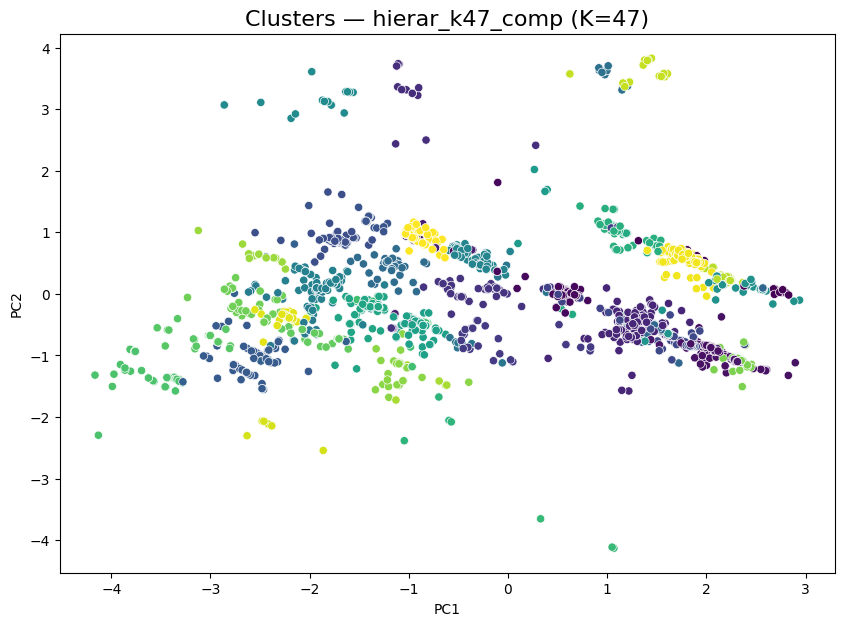

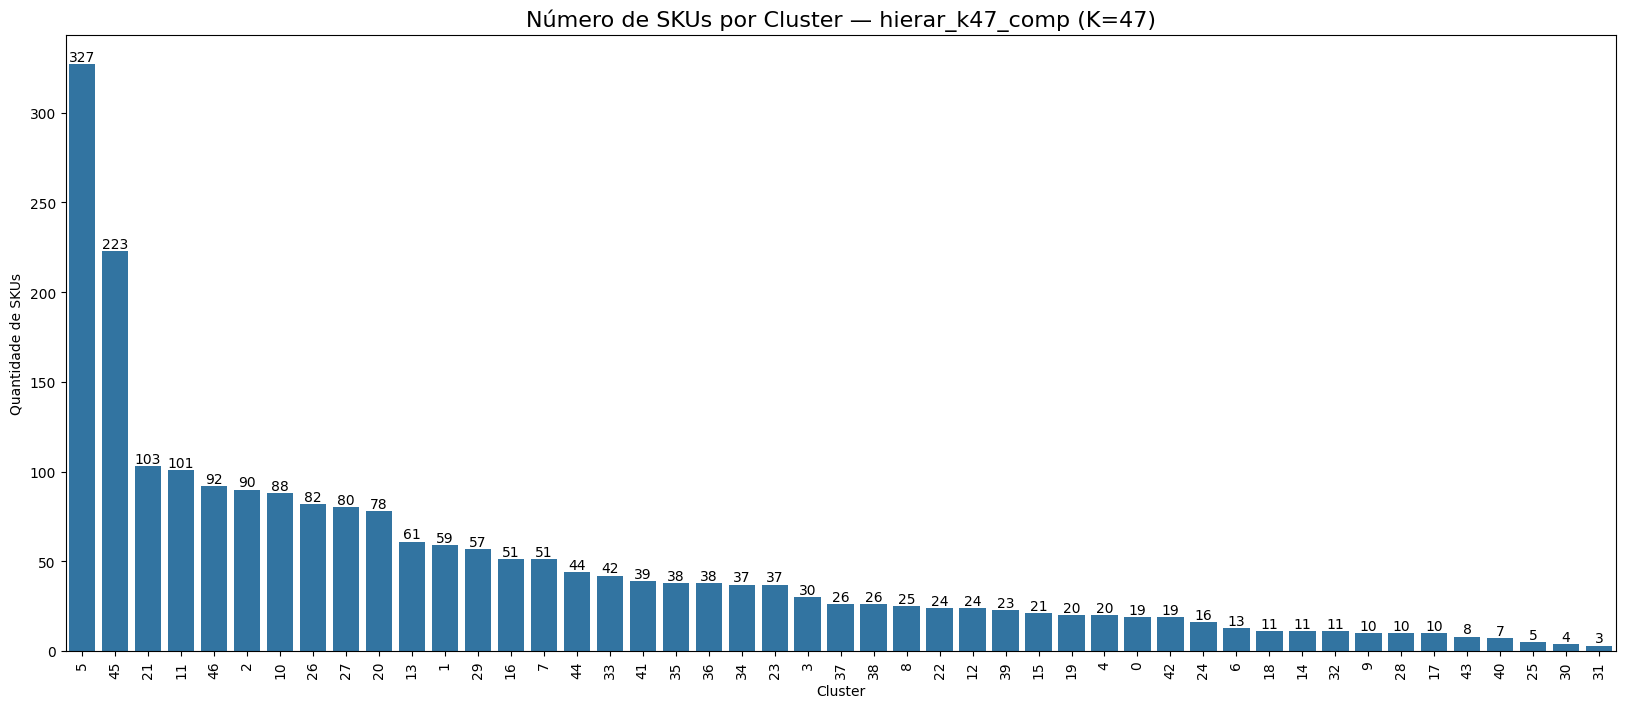

qt_altura_material                             \
                              mean        std     min     max   
hierar_k47_comp                                                 
0                       197.105263  18.095103  165.00  215.00   
1                       148.288136  10.148978  105.00  160.00   
2                       205.333333   9.254213  190.00  245.00   
3                       200.700000  12.487649  175.00  212.00   
4                       132.000000   8.926601  120.00  151.00   
5                       177.599388   4.443414  155.00  188.00   
6                        60.703077  41.748355   30.00  150.00   
7                       166.627451   8.768035  145.00  188.00   
8                       176.270000  12.365510  160.00  193.00   
9                       151.700000   6.147267  145.00  166.00   
10                      195.443182   7.430688  170.00  210.00   
11                      117.673267   5.894250  105.00  130.00   
12                      102.041667  19.581445   40.00  120.00   
13                      131.590164  10.160999  114.00  152.00   
14                      125.090909  15.507769  100.00  140.00   
15                      185.428571   9.754852  175.00  205.00   
16                      137.098039   6.637032  118.00  148.00   
17                       54.452000  12.114234   46.84   77.52   
18                      168.800000   8.234804  160.00  185.00   
19                      147.350000   9.831609  131.00  160.00   
20                      128.307692   7.950019  110.00  153.00   
21                      151.087379   7.227205  139.00  170.00   
22                       37.375000  10.154513   18.00   57.00   
23                      206.918919   5.149856  200.00  223.00   
24                      184.937500   5.638779  174.00  191.00   
25                       55.200000  12.498000   45.00   77.00   
26                      147.409756   4.543768  135.00  159.00   
27                      123.300000   7.091446  105.00  140.00   
28                      162.800000  14.171960  148.00  191.00   
29                      152.736842  10.388053  128.00  170.00   
30                       69.552500  14.753480   47.43   77.46   
31                      201.333333  14.153916  185.00  210.00   
32                      144.272727  14.880127  120.00  167.00   
33                      106.571429  11.555049   77.00  122.00   
34                      103.837838   6.313625   90.00  120.00   
35                      139.526316   4.548459  130.00  152.00   
36                      111.368421   8.419479   97.00  129.00   
37                      211.622692   4.278667  200.00  220.00   
38                      166.807692   6.511646  149.00  184.00   
39                       98.695652  13.271414   45.00  115.00   
40                      178.571429   8.223080  164.00  184.00   
41                      196.205128   5.666984  182.00  205.00   
42                       66.213158  14.210020   47.14   77.60   
43                      163.000000   7.348469  156.00  180.00   
44                      112.704545   3.991733   96.00  120.00   
45                      179.125561   4.583797  170.00  195.00   
46                      127.141304   7.133856  118.00  150.00   

                diametro_material                        \
                             mean       std   min   max   
hierar_k47_comp                                           
0                       50.000000  0.000000  50.0  50.0   
1                       50.000000  0.000000  50.0  50.0   
2                       50.000000  0.000000  50.0  50.0   
3                       50.000000  0.000000  50.0  50.0   
4                       39.750000  1.118034  35.0  40.0   
5                       50.000000  0.000000  50.0  50.0   
6                       38.076923  2.531848  35.0  40.0   
7                       37.647059  3.369413  30.0  40.0   
8                       40.600000  2.629956  35.0  45.0   
9                       50.000000  0.000000  50.0  50.0  


  Experimento: hierar_k47_comp
  - Pontuação de Silhueta:     0.5582 (Maior é melhor)
  - Índice de Davies-Bouldin:  0.8128 (Menor é melhor)
  - Correlação Cofenética:     0.7216 (Maior é melhor)
  ✓ Artefatos salvos em: ../models/hierar_k47_comp/


In [6]:
k = 47
nome = 'hierar_k47_comp'
dados = dados_para_modelo_completo

modelo = AgglomerativeClustering(n_clusters=k, linkage='ward')
inicio = time.time()
clusters = modelo.fit_predict(dados)
tempo = time.time() - inicio
print(f"Tempo de treinamento: {tempo:.4f}s")

score_sil = silhouette_score(dados, clusters)
score_db = davies_bouldin_score(dados, clusters)
linked = sch.linkage(dados, method='ward')
dist_cof, _ = sch.cophenet(linked, pdist(dados))

salvar_artefatos(nome, modelo, dados, clusters, df_bis.copy(),
                 colunas_perfil_comp, nome, k, 'Hierárquico Ward',
                 score_sil, score_db, dist_cof)

---
## Experimento 2 — Hierárquico Ward K=47 (Sem comprimento)

Tempo de treinamento: 0.0834s


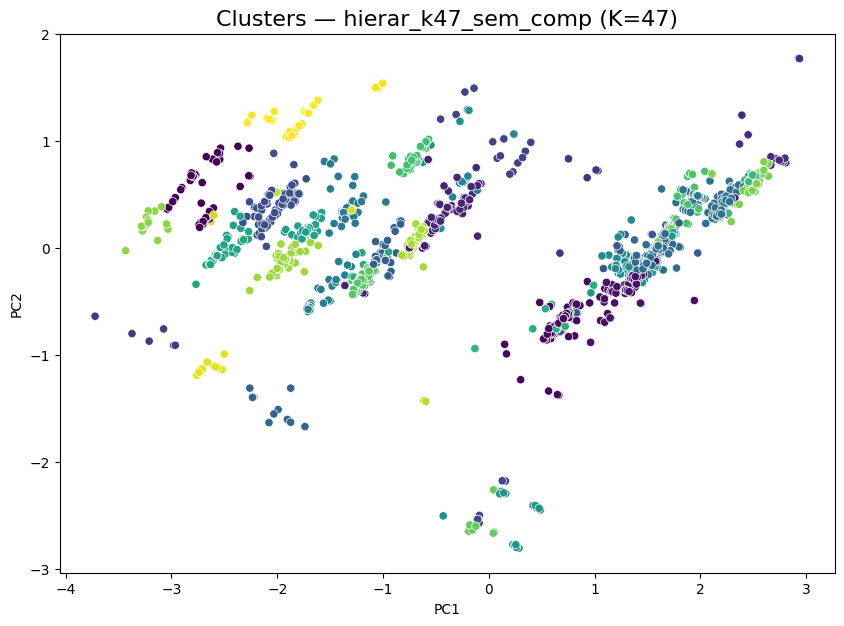

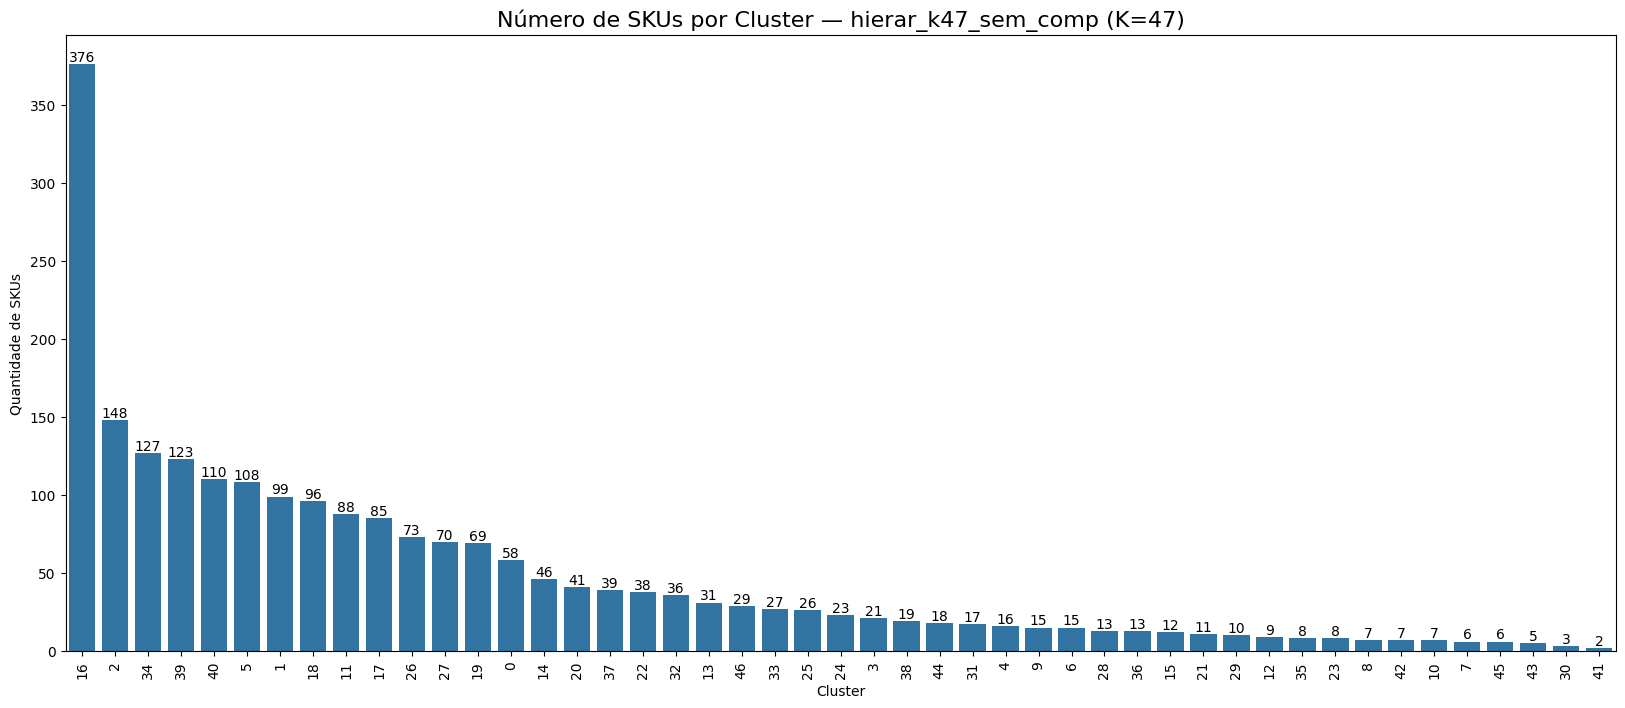

qt_altura_material                             \
                                  mean        std     min     max   
hierar_k47_sem_comp                                                 
0                           117.724138  10.668519  104.00  140.00   
1                           150.171717   6.954723  128.00  168.00   
2                           172.148649   4.808390  150.00  176.00   
3                           185.428571   9.754852  175.00  205.00   
4                           141.375000  14.282273  120.00  167.00   
5                           158.914352   5.113908  150.00  175.00   
6                           223.600000   9.038015  215.00  245.00   
7                           187.000000  13.281566  160.00  193.00   
8                            27.571429  11.207990   18.00   45.00   
9                           183.533333   4.273952  177.00  192.00   
10                           56.645714  14.141171   46.84   77.52   
11                          127.136364   7.597915  111.00  145.00   
12                          163.666667  14.747881  148.00  191.00   
13                          185.193548   5.075558  170.00  191.00   
14                          137.565217   6.181162  130.00  150.00   
15                           39.595000   8.576709   30.00   63.00   
16                          180.220745   2.746478  176.00  190.00   
17                          203.764706   3.503899  197.00  210.00   
18                          199.062500   2.827729  195.00  210.00   
19                          141.710145   4.190681  131.00  153.00   
20                          112.317073   8.719057  104.00  133.00   
21                          168.800000   8.234804  160.00  185.00   
22                          177.184211   4.085937  174.00  190.00   
23                          175.125000  12.368595  151.00  184.00   
24                           66.793913  14.020257   47.14   77.60   
25                          181.346154   8.527332  155.00  191.00   
26                          127.479452   3.005133  125.00  137.00   
27                          103.714286   6.079528   83.00  118.00   
28                          129.923077   6.143581  120.00  135.00   
29                          151.700000   6.147267  145.00  166.00   
30                          136.333333  14.433757  128.00  153.00   
31                          210.823529   2.920516  200.00  212.00   
32                          165.888889   3.631432  160.00  173.00   
33                          202.851852   5.296615  195.00  210.00   
34                          123.692913   3.646072  117.00  130.00   
35                           53.000000   9.985704   45.00   77.00   
36                          187.461538   5.516874  175.00  191.00   
37                          211.543333   3.624634  200.00  220.00   
38                           94.473684   5.660471   77.00  104.00   
39                          114.544715   4.349961   96.00  125.00   
40                          145.150909   3.023569  138.00  151.00   
41                          105.000000   0.000000  105.00  105.00   
42                          116.571429  12.959644  100.00  130.00   
43                          137.000000   6.708204  125.00  140.00   
44                           41.611111   6.325847   32.00   57.00   
45                          178.333333   0.816497  178.00  180.00   
46                          154.551724   4.548047  147.00  165.00   

                    diametro_material                       qt_peso_bruto  \
                                 mean       std   min   max          mean   
hierar_k47_sem_comp                                                         
0                           21.551724  2.950899  19.0  25.0     32.098862   
1                           50.000000  0.000000  50.0  50.0    174.754222   
2                           50.000000  0.000000  50.0  50.0    224.130419   
3                           50.000000  0.000000  50.0  50.0    235.120476   
4                           39


  Experimento: hierar_k47_sem_comp
  - Pontuação de Silhueta:     0.5578 (Maior é melhor)
  - Índice de Davies-Bouldin:  0.6119 (Menor é melhor)
  - Correlação Cofenética:     0.8060 (Maior é melhor)
  ✓ Artefatos salvos em: ../models/hierar_k47_sem_comp/


In [7]:
k = 47
nome = 'hierar_k47_sem_comp'
dados = dados_para_modelo_sem_comp

modelo = AgglomerativeClustering(n_clusters=k, linkage='ward')
inicio = time.time()
clusters = modelo.fit_predict(dados)
tempo = time.time() - inicio
print(f"Tempo de treinamento: {tempo:.4f}s")

score_sil = silhouette_score(dados, clusters)
score_db = davies_bouldin_score(dados, clusters)
linked = sch.linkage(dados, method='ward')
dist_cof, _ = sch.cophenet(linked, pdist(dados))

salvar_artefatos(nome, modelo, dados, clusters, df_bis.copy(),
                 colunas_perfil_sem_comp, nome, k, 'Hierárquico Ward',
                 score_sil, score_db, dist_cof)

---
## Experimento 3 — Hierárquico Ward K=65 (Completo)

Tempo de treinamento: 0.0914s


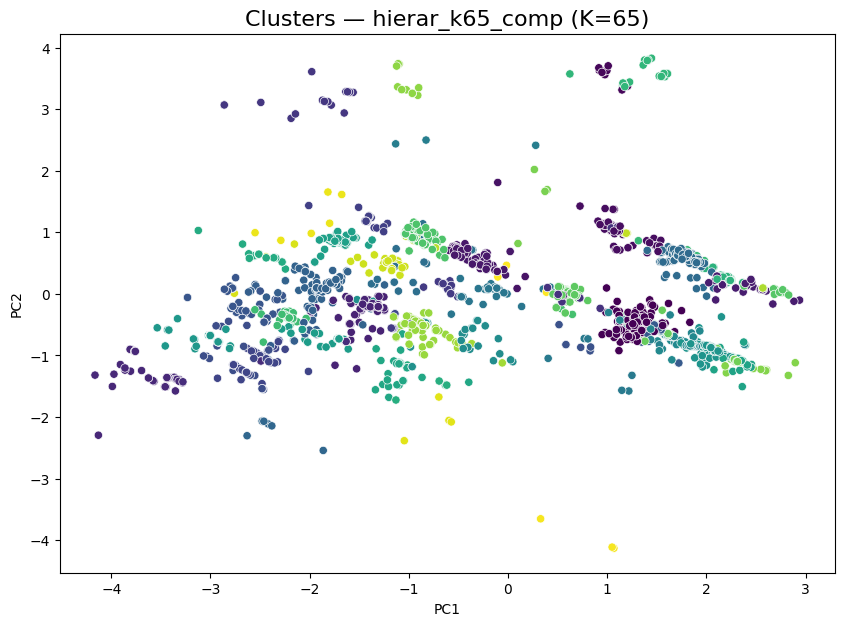

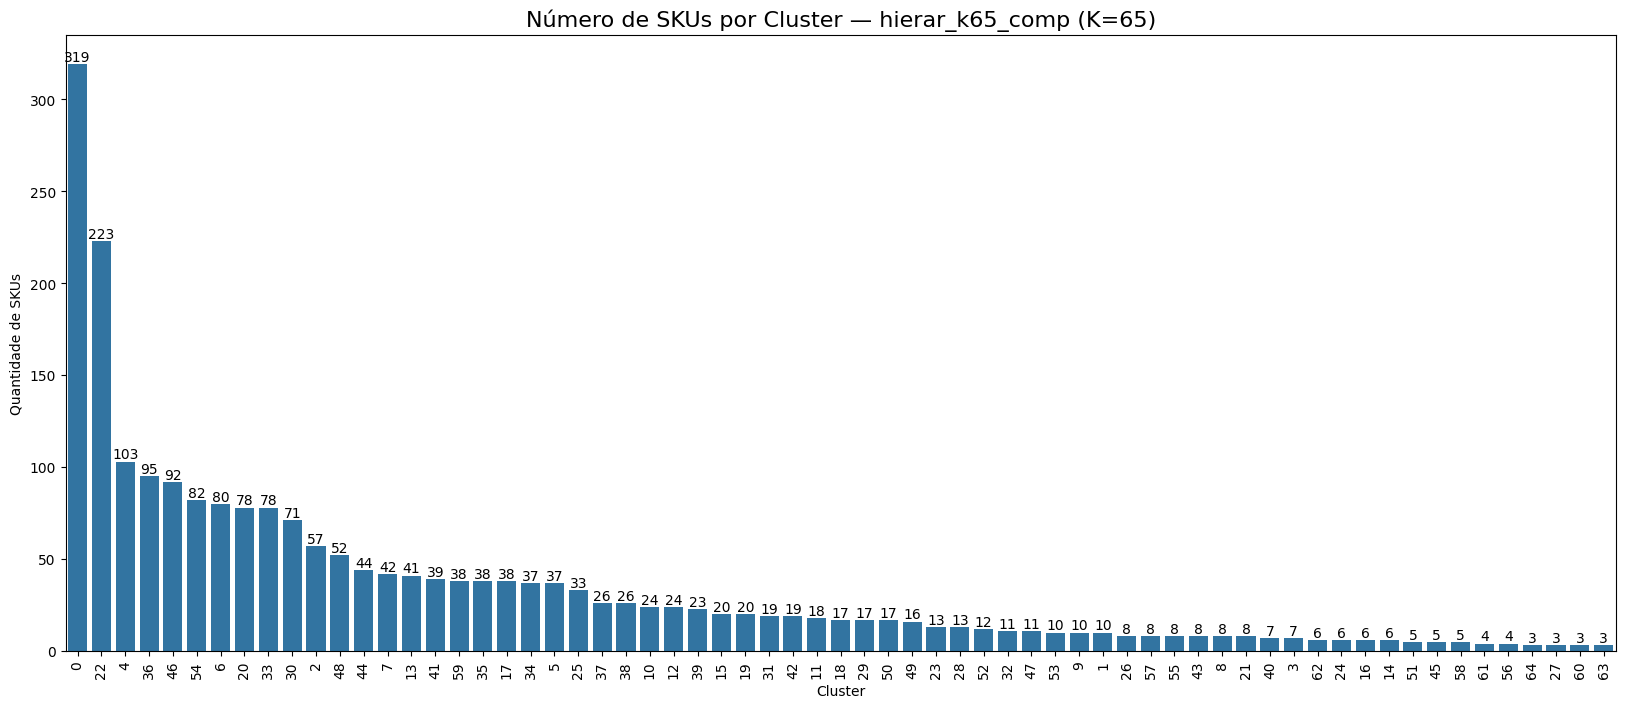

qt_altura_material                             \
                              mean        std     min     max   
hierar_k65_comp                                                 
0                       177.836991   3.616665  162.00  188.00   
1                        54.452000  12.114234   46.84   77.52   
2                       152.736842  10.388053  128.00  170.00   
3                       127.428571  17.462886  105.00  153.00   
4                       151.087379   7.227205  139.00  170.00   
...                            ...        ...     ...     ...   
60                      105.333333   4.725816  100.00  109.00   
61                       69.552500  14.753480   47.43   77.46   
62                      113.500000   5.540758  105.00  120.00   
63                      201.333333  14.153916  185.00  210.00   
64                      172.133333  11.142860  165.70  185.00   

                diametro_material                        \
                             mean       std   min   max   
hierar_k65_comp                                           
0                       50.000000  0.000000  50.0  50.0   
1                       50.000000  0.000000  50.0  50.0   
2                       50.000000  0.000000  50.0  50.0   
3                       50.000000  0.000000  50.0  50.0   
4                       39.990291  0.098533  39.0  40.0   
...                           ...       ...   ...   ...   
60                      28.333333  2.886751  25.0  30.0   
61                      50.000000  0.000000  50.0  50.0   
62                      22.333333  4.457204  19.0  30.0   
63                      50.000000  0.000000  50.0  50.0   
64                      40.000000  0.000000  40.0  40.0   

                qt_comprimento_material                           \
                                   mean        std    min    max   
hierar_k65_comp                                                    
0                             49.169279   2.119733   41.0   57.0   
1                            181.700000   5.696978  172.0  193.0   
2                             76.614035   3.177793   68.0   80.0   
3                             53.857143  11.582006   47.0   80.0   
4                             61.203883   1.762125   60.0   72.0   
...                                 ...        ...    ...    ...   
60                            46.333333   7.023769   39.0   53.0   
61                            20.250000   1.206924   18.6   21.5   
62                            64.416667  10.160791   53.0   77.0   
63                            19.000000   0.000000   19.0   19.0   
64                            62.333333   2.516611   60.0   65.0   

                qt_peso_bruto                               
                         mean        std      min      max  
hierar_k65_comp                                             
0                  223.137100  11.377281  176.000  319.244  
1                  223.108500   4.382209  219.000  231.180  
2                  187.683123  20.962525  165.690  228.000  
3                  114.918000  23.232061   91.890  145.496  
4                  122.190437   6.005831  109.600  142.705  
...                       ...        ...      ...      ...  
60                  39.462000   4.379992   36.000   44.386  
61                 263.500000  29.149042  220.000  281.000  
62                  66.628333  22.146440   26.000   87.000  
63                 254.333333  30.599564  219.000  272.000  
64                 124.118667  11.758309  116.386  137.650  

[65 rows x 16 columns]


  Experimento: hierar_k65_comp
  - Pontuação de Silhueta:     0.5872 (Maior é melhor)
  - Índice de Davies-Bouldin:  0.7268 (Menor é melhor)
  - Correlação Cofenética:     0.7216 (Maior é melhor)
  ✓ Artefatos salvos em: ../models/hierar_k65_comp/


In [8]:
k = 65
nome = 'hierar_k65_comp'
dados = dados_para_modelo_completo

modelo = AgglomerativeClustering(n_clusters=k, linkage='ward')
inicio = time.time()
clusters = modelo.fit_predict(dados)
tempo = time.time() - inicio
print(f"Tempo de treinamento: {tempo:.4f}s")

score_sil = silhouette_score(dados, clusters)
score_db = davies_bouldin_score(dados, clusters)
linked = sch.linkage(dados, method='ward')
dist_cof, _ = sch.cophenet(linked, pdist(dados))

salvar_artefatos(nome, modelo, dados, clusters, df_bis.copy(),
                 colunas_perfil_comp, nome, k, 'Hierárquico Ward',
                 score_sil, score_db, dist_cof)

---
## Experimento 4 — Hierárquico Ward K=65 (Sem comprimento)

Tempo de treinamento: 0.0846s


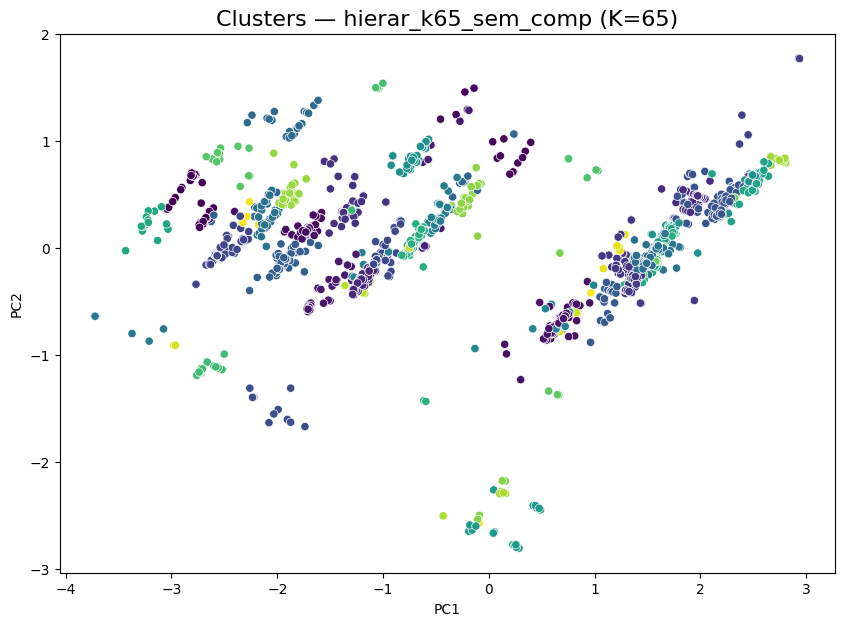

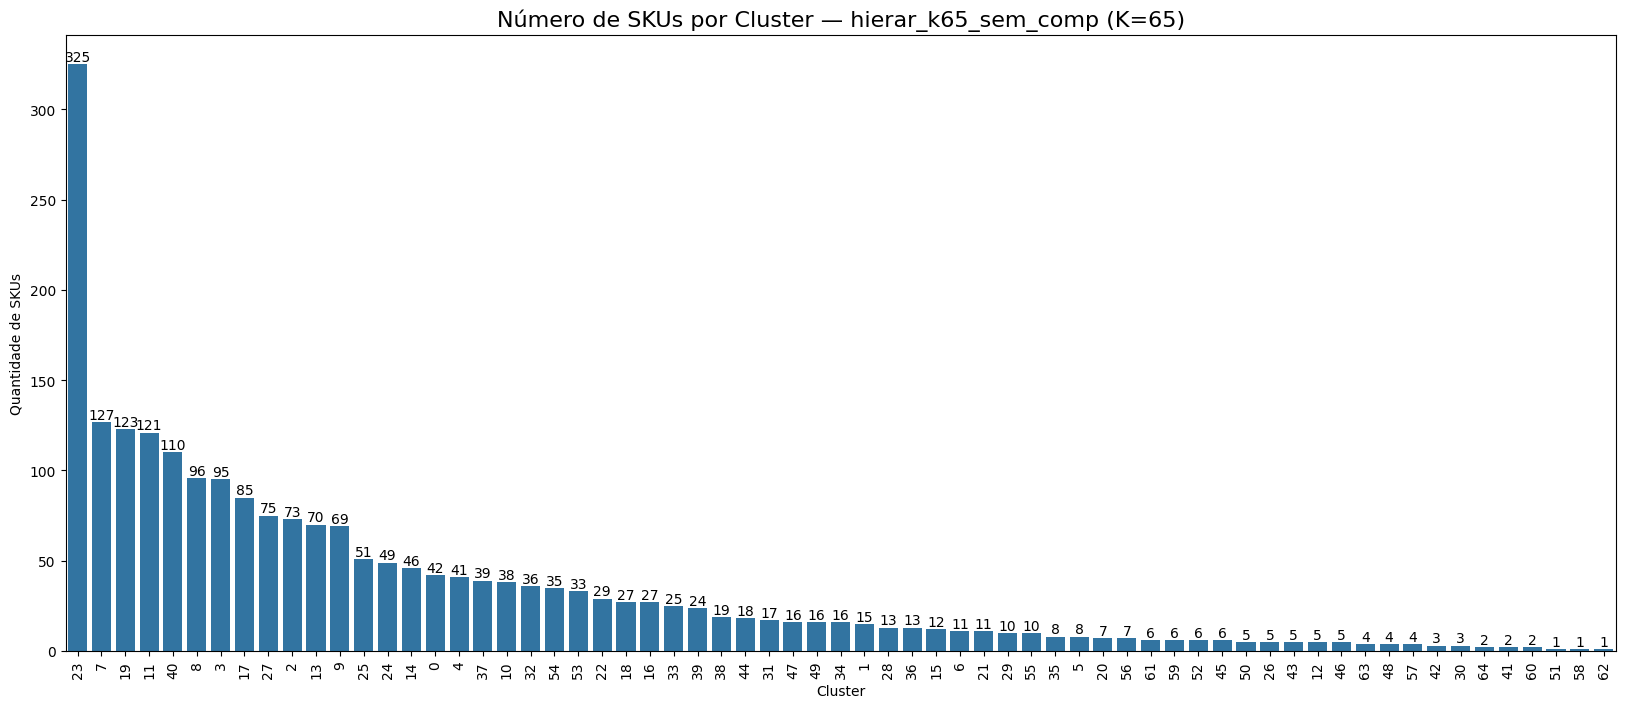

qt_altura_material                          \
                                  mean       std    min    max   
hierar_k65_sem_comp                                              
0                           112.166667  6.301052  104.0  122.0   
1                           183.533333  4.273952  177.0  192.0   
2                           127.479452  3.005133  125.0  137.0   
3                           151.105263  5.350430  128.0  168.0   
4                           112.317073  8.719057  104.0  133.0   
...                                ...       ...    ...    ...   
60                           22.500000  0.707107   22.0   23.0   
61                          177.000000  3.898718  170.0  182.0   
62                           50.000000       NaN   50.0   50.0   
63                          114.750000  3.774917  111.0  120.0   
64                          160.000000  7.071068  155.0  165.0   

                    diametro_material                       qt_peso_bruto  \
                                 mean       std   min   max          mean   
hierar_k65_sem_comp                                                         
0                           22.000000  3.036365  19.0  25.0     30.864000   
1                           38.666667  2.288689  35.0  40.0    147.272733   
2                           35.000000  0.000000  35.0  35.0     57.398493   
3                           50.000000  0.000000  50.0  50.0    172.734168   
4                           40.000000  0.000000  40.0  40.0     66.873244   
...                               ...       ...   ...   ...           ...   
60                          19.000000  0.000000  19.0  19.0     92.440000   
61                          50.000000  0.000000  50.0  50.0    176.330667   
62                          50.000000       NaN  50.0  50.0    224.735000   
63                          19.750000  1.500000  19.0  22.0     81.630000   
64                          50.000000  0.000000  50.0  50.0    172.215000   

                                                  
                           std      min      max  
hierar_k65_sem_comp                               
0                     5.654108   22.800   41.500  
1                    21.388027  113.000  169.000  
2                     9.131741   12.000   71.000  
3                     8.698574  132.000  200.056  
4                     4.645055   61.000   76.800  
...                        ...      ...      ...  
60                    0.933381   91.780   93.100  
61                    2.487045  173.600  180.354  
62                         NaN  224.735  224.735  
63                    4.493247   76.000   87.000  
64                    0.445477  171.900  172.530  

[65 rows x 12 columns]


  Experimento: hierar_k65_sem_comp
  - Pontuação de Silhueta:     0.5746 (Maior é melhor)
  - Índice de Davies-Bouldin:  0.5195 (Menor é melhor)
  - Correlação Cofenética:     0.8060 (Maior é melhor)
  ✓ Artefatos salvos em: ../models/hierar_k65_sem_comp/


In [9]:
k = 65
nome = 'hierar_k65_sem_comp'
dados = dados_para_modelo_sem_comp

modelo = AgglomerativeClustering(n_clusters=k, linkage='ward')
inicio = time.time()
clusters = modelo.fit_predict(dados)
tempo = time.time() - inicio
print(f"Tempo de treinamento: {tempo:.4f}s")

score_sil = silhouette_score(dados, clusters)
score_db = davies_bouldin_score(dados, clusters)
linked = sch.linkage(dados, method='ward')
dist_cof, _ = sch.cophenet(linked, pdist(dados))

salvar_artefatos(nome, modelo, dados, clusters, df_bis.copy(),
                 colunas_perfil_sem_comp, nome, k, 'Hierárquico Ward',
                 score_sil, score_db, dist_cof)

---
## Experimento 5 — K-Means K=47 (Completo)

Tempo de treinamento: 0.3216s


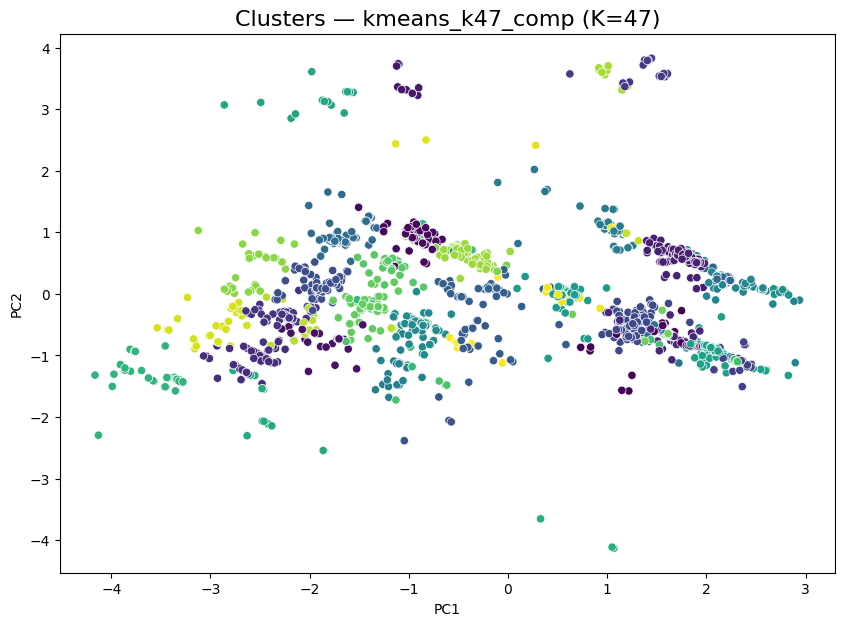

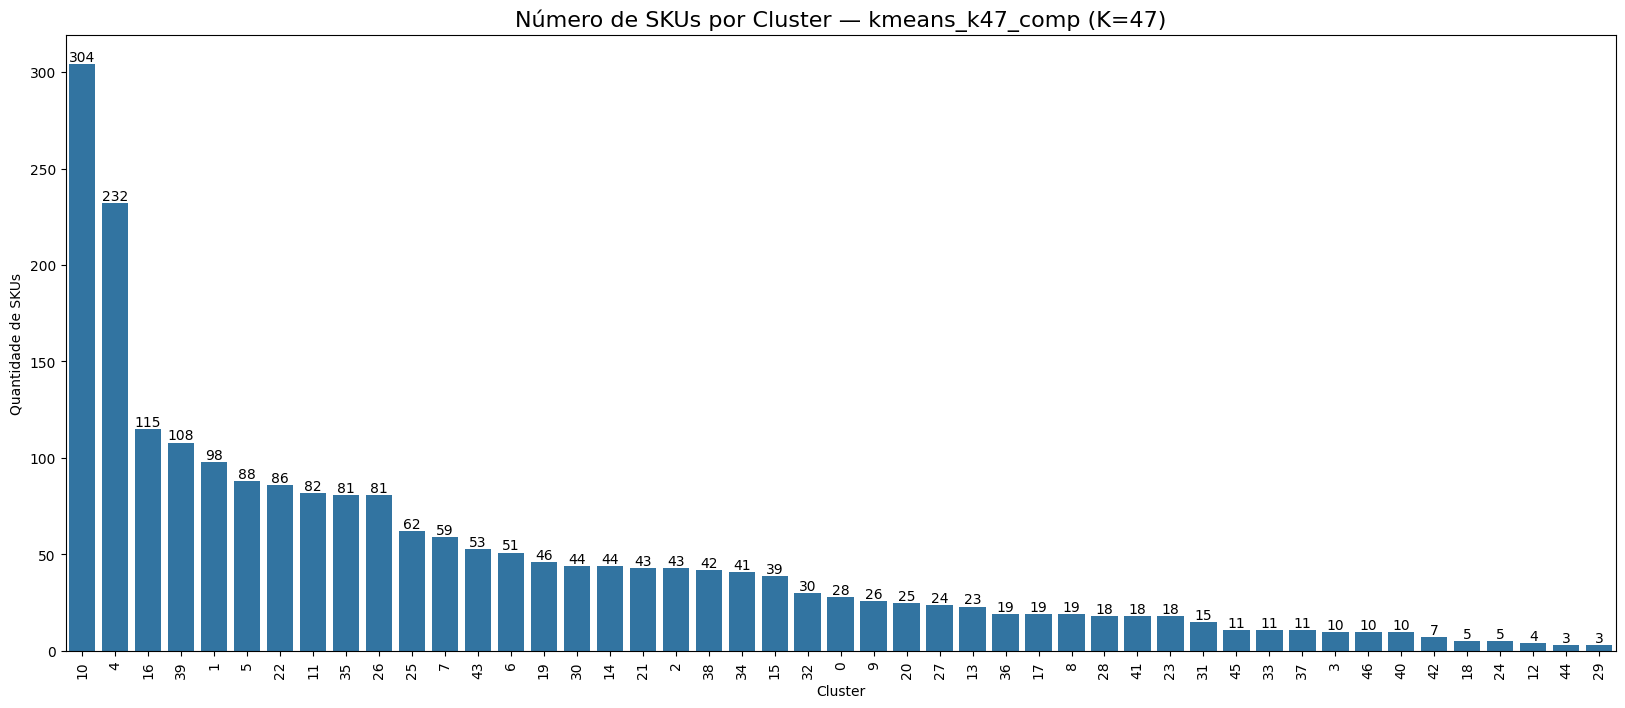

qt_altura_material                             \
                              mean        std     min     max   
kmeans_k47_comp                                                 
0                       189.000000   4.562326  185.00  200.00   
1                       124.836735  10.599255   40.00  140.00   
2                       139.837209   5.282181  127.00  153.00   
3                        39.514000   9.479602   30.00   63.00   
4                       178.215517   5.129165  160.00  190.00   
5                       195.443182   7.430688  170.00  210.00   
6                       127.725490   6.346900  114.00  143.00   
7                       112.932203   4.730183   96.00  125.00   
8                        66.213158  14.210020   47.14   77.60   
9                       211.622692   4.278667  200.00  220.00   
10                      177.516447   3.117034  164.00  184.00   
11                      127.182927   6.890910  115.00  151.00   
12                       69.552500  14.753480   47.43   77.46   
13                      174.554348  11.507892  160.00  193.00   
14                      166.340909   7.578867  155.00  188.00   
15                      196.205128   5.666984  182.00  205.00   
16                      115.469565   9.967774   40.00  130.00   
17                      183.368421   7.660944  175.00  200.00   
18                       55.200000  12.498000   45.00   77.00   
19                      148.369565  10.910461  105.00  168.00   
20                      166.120000   5.600000  149.00  180.00   
21                      206.883721   8.220790  195.00  245.00   
22                      147.309302   4.832309  135.00  160.00   
23                      198.888889  16.813471  174.00  215.00   
24                      131.200000   6.260990  120.00  134.00   
25                      150.516129   7.636714  105.00  162.00   
26                      205.925926   7.856172  197.00  245.00   
27                       37.375000  10.154513   18.00   57.00   
28                      156.500000   7.763035  147.00  180.00   
29                      201.333333  14.153916  185.00  210.00   
30                      106.681818  11.296784   77.00  122.00   
31                      141.466667  14.778685  120.00  167.00   
32                      200.700000  12.487649  175.00  212.00   
33                      164.545455  20.476150  140.00  184.00   
34                      140.634146   5.209396  128.00  161.00   
35                      124.000000   6.166441  105.00  140.00   
36                      183.631579   8.750940  155.00  191.00   
37                      132.245455  12.312706  120.00  165.70   
38                      105.714286  14.547292   45.00  135.00   
39                      150.657407   6.850762  139.00  170.00   
40                       54.452000  12.114234   46.84   77.52   
41                      159.611111  12.593831  138.00  178.00   
42                      159.285714   5.794086  156.00  170.00   
43                      105.830189   8.818110   90.00  130.00   
44                      131.333333  18.036999  114.00  150.00   
45                      151.818182   5.844967  145.00  166.00   
46                      169.110000   8.612323  160.00  185.00   

                diametro_material                        \
                             mean       std   min   max   
kmeans_k47_comp                                           
0                       49.464286  1.574852  45.0  50.0   
1                       40.000000  0.000000  40.0  40.0   
2                       34.065116  2.499798  30.0  40.0   
3                       38.500000  2.415229  35.0  40.0   
4                       50.000000  0.000000  50.0  50.0   
5                       50.000000  0.000000  50.0  50.0   
6                       28.078431  3.509092  19.0  35.0   
7                       34.403390  2.289554  30.0  40.0   
8                       50.000000  0.000000  50.0  50.0   
9                       50.000000  0.000000  50.0  50.0  


  Experimento: kmeans_k47_comp
  - Pontuação de Silhueta:     0.5386 (Maior é melhor)
  - Índice de Davies-Bouldin:  0.7893 (Menor é melhor)
  ✓ Artefatos salvos em: ../models/kmeans_k47_comp/


In [10]:
k = 47
nome = 'kmeans_k47_comp'
dados = dados_para_modelo_completo

modelo = KMeans(n_clusters=k, n_init=10, random_state=50)
inicio = time.time()
clusters = modelo.fit_predict(dados)
tempo = time.time() - inicio
print(f"Tempo de treinamento: {tempo:.4f}s")

score_sil = silhouette_score(dados, clusters)
score_db = davies_bouldin_score(dados, clusters)

salvar_artefatos(nome, modelo, dados, clusters, df_bis.copy(),
                 colunas_perfil_comp, nome, k, 'K-Means',
                 score_sil, score_db)

---
## Experimento 6 — K-Means K=47 (Sem comprimento)

Tempo de treinamento: 0.1955s


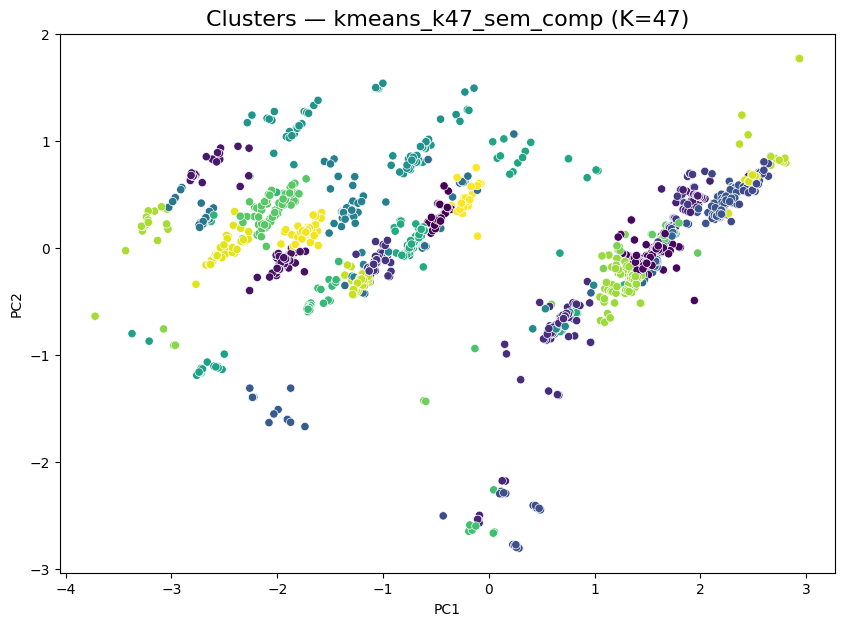

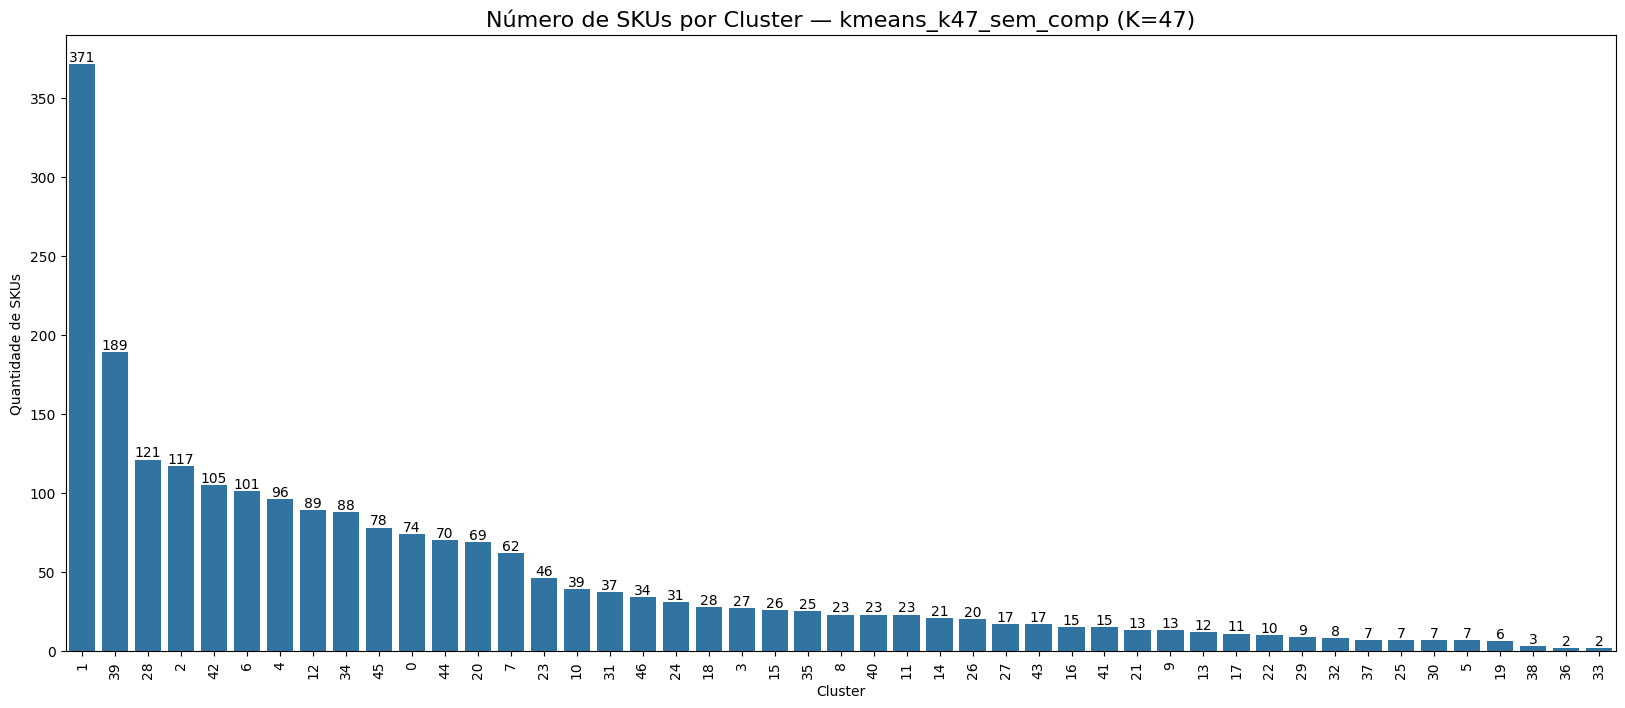

qt_altura_material                             \
                                  mean        std     min     max   
kmeans_k47_sem_comp                                                 
0                           156.351351   3.146785  150.00  166.00   
1                           180.431267   2.770987  175.00  190.00   
2                           114.136752   4.034134   96.00  121.00   
3                           127.370370   6.196452  119.00  140.00   
4                           199.062500   2.827729  195.00  210.00   
5                            56.645714  14.141171   46.84   77.52   
6                           150.168317   6.884866  128.00  168.00   
7                           132.419355   3.527635  128.00  142.00   
8                           203.826087   5.051122  195.00  210.00   
9                           187.461538   5.516874  175.00  191.00   
10                          211.543333   3.624634  200.00  220.00   
11                           66.793913  14.020257   47.14   77.60   
12                          203.471910   3.714498  195.00  210.00   
13                           39.595000   8.576709   30.00   63.00   
14                          185.428571   9.754852  175.00  205.00   
15                          181.346154   8.527332  155.00  191.00   
16                          141.466667  14.778685  120.00  167.00   
17                          168.800000   8.234804  160.00  185.00   
18                          108.892857   2.806597  105.00  115.00   
19                          139.333333   8.286535  125.00  151.00   
20                          141.710145   4.190681  131.00  153.00   
21                          129.923077   6.143581  120.00  135.00   
22                          151.700000   6.147267  145.00  166.00   
23                          169.282609   7.629367  160.00  192.00   
24                          153.870968   5.129925  143.00  165.00   
25                          178.571429   8.223080  164.00  184.00   
26                           40.950000   7.104298   25.00   57.00   
27                          184.117647   8.207332  160.00  193.00   
28                          145.327273   3.158349  138.00  151.00   
29                          163.666667  14.747881  148.00  191.00   
30                          116.571429  12.959644  100.00  130.00   
31                          110.594595   7.216722  104.00  128.00   
32                           53.000000   9.985704   45.00   77.00   
33                          128.000000   0.000000  128.00  128.00   
34                          126.704545   7.225687  111.00  142.00   
35                          187.160000   2.867635  182.00  191.00   
36                          105.000000   0.000000  105.00  105.00   
37                          173.571429   9.744351  153.00  182.00   
38                           29.000000  11.269428   22.00   42.00   
39                          173.195767   3.878306  158.00  178.00   
40                           88.652174  23.036747   18.00  104.00   
41                          223.600000   9.038015  215.00  245.00   
42                          122.495238   2.808380  117.00  128.00   
43                          210.823529   2.920516  200.00  212.00   
44                          103.814286   6.368612   83.00  125.00   
45                          127.128205   3.232782  120.00  137.00   
46                          164.492647   4.012521  155.00  175.00   

                    diametro_material                       qt_peso_bruto  \
                                 mean       std   min   max          mean   
kmeans_k47_sem_comp                                                         
0                           39.986486  0.116248  39.0  40.0    124.830027   
1                           50.000000  0.000000  50.0  50.0    225.552760   
2                           34.977778  0.063124  34.8  35.0     61.095462   
3                           19.592593  1.670082  19.0  25.0     30.950593   
4                           50


  Experimento: kmeans_k47_sem_comp
  - Pontuação de Silhueta:     0.5453 (Maior é melhor)
  - Índice de Davies-Bouldin:  0.5688 (Menor é melhor)
  ✓ Artefatos salvos em: ../models/kmeans_k47_sem_comp/


In [11]:
k = 47
nome = 'kmeans_k47_sem_comp'
dados = dados_para_modelo_sem_comp

modelo = KMeans(n_clusters=k, n_init=10, random_state=50)
inicio = time.time()
clusters = modelo.fit_predict(dados)
tempo = time.time() - inicio
print(f"Tempo de treinamento: {tempo:.4f}s")

score_sil = silhouette_score(dados, clusters)
score_db = davies_bouldin_score(dados, clusters)

salvar_artefatos(nome, modelo, dados, clusters, df_bis.copy(),
                 colunas_perfil_sem_comp, nome, k, 'K-Means',
                 score_sil, score_db)

---
## Experimento 7 — K-Means K=65 (Completo)

Tempo de treinamento: 0.2801s


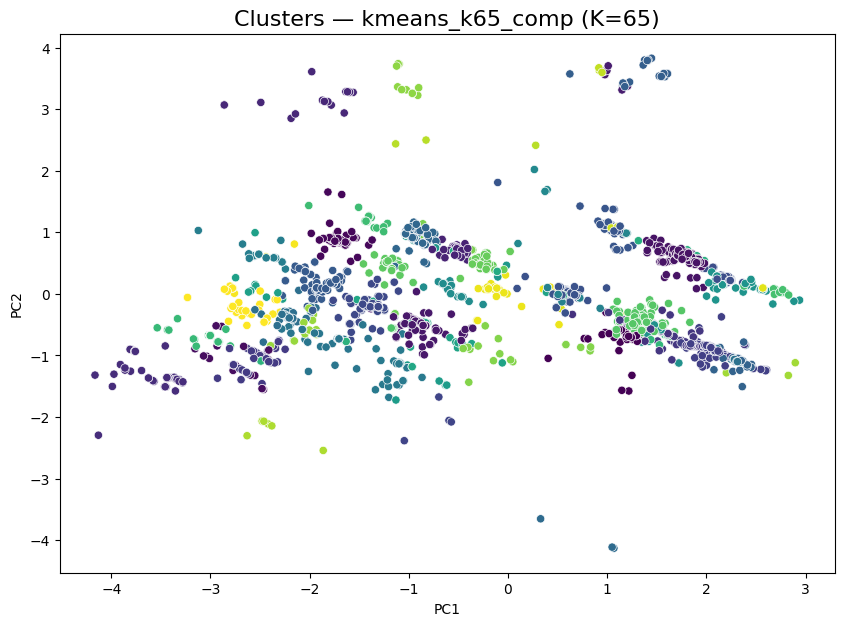

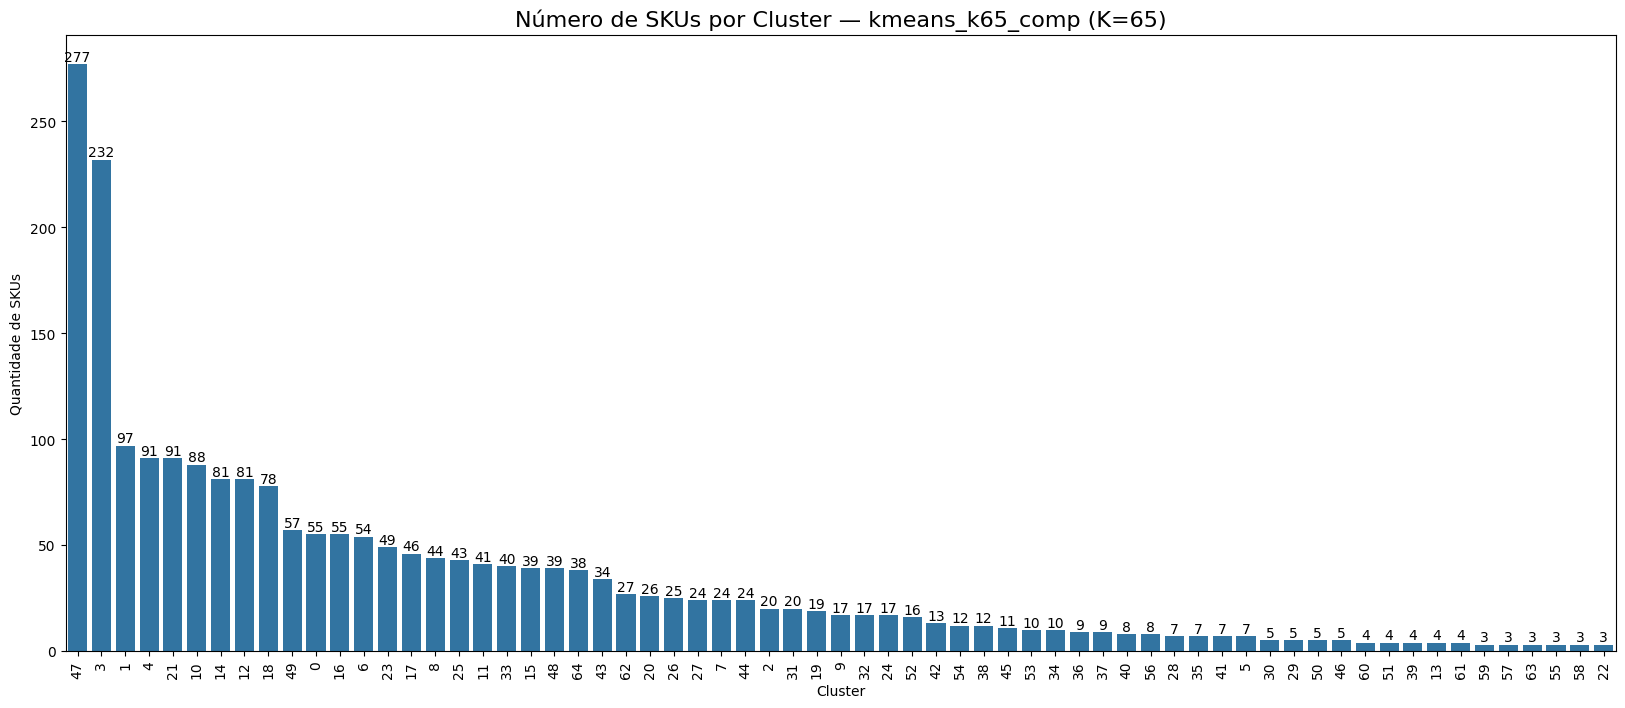

qt_altura_material                          diametro_material  \
                              mean        std    min    max              mean   
kmeans_k65_comp                                                                 
0                       175.690909   7.033972  155.0  186.0         50.000000   
1                       118.082474   5.975070  105.0  130.0         34.459794   
2                       141.700000  10.829297  120.0  155.0         21.550000   
3                       178.215517   5.129165  160.0  190.0         50.000000   
4                       148.797802   6.243183  138.0  165.0         39.934066   
...                            ...        ...    ...    ...               ...   
60                      173.250000  18.962683  148.0  191.0         50.000000   
61                      192.500000  14.433757  180.0  205.0         50.000000   
62                      167.000000   8.426150  155.0  188.0         40.000000   
63                      105.333333   4.725816  100.0  109.0         28.333333   
64                      111.894737   9.030846   97.0  130.0         28.263158   

                                      qt_comprimento_material                  \
                      std   min   max                    mean       std   min   
kmeans_k65_comp                                                                 
0                0.000000  50.0  50.0               44.054545  2.850719  35.0   
1                2.657876  19.0  35.0               56.613402  3.587816  50.0   
2                2.438183  19.0  25.0               30.700000  2.028741  28.0   
3                0.000000  50.0  50.0               77.344828  2.587360  64.0   
4                0.533379  35.0  40.0               39.747253  1.683867  35.0   
...                   ...   ...   ...                     ...       ...   ...   
60               0.000000  50.0  50.0               48.750000  2.500000  45.0   
61               0.000000  50.0  50.0               78.000000  0.000000  78.0   
62               0.000000  40.0  40.0               54.370370  4.524703  45.0   
63               2.886751  25.0  30.0               46.333333  7.023769  39.0   
64               3.133810  20.0  35.0               36.736842  2.177082  35.0   

                      qt_peso_bruto                               
                  max          mean        std      min      max  
kmeans_k65_comp                                                   
0                48.0    221.453109  12.482801  178.750  246.310  
1                77.0     59.560247   7.705188   47.000   87.000  
2                35.0     41.278400   9.076038   26.170   56.000  
3                80.0    224.233504   9.656860  172.000  268.330  
4                46.0    117.772538  10.884377   90.900  142.900  
...               ...           ...        ...      ...      ...  
60               50.0    206.363250  22.997655  172.872  222.403  
61               78.0    250.000000  28.867513  225.000  275.000  
62               62.0    152.287852  29.301626  131.310  287.490  
63               53.0     39.462000   4.379992   36.000   44.386  
64               41.0     41.105105   9.278552   12.000   61.310  

[65 rows x 16 columns]


  Experimento: kmeans_k65_comp
  - Pontuação de Silhueta:     0.5728 (Maior é melhor)
  - Índice de Davies-Bouldin:  0.6218 (Menor é melhor)
  ✓ Artefatos salvos em: ../models/kmeans_k65_comp/


In [12]:
k = 65
nome = 'kmeans_k65_comp'
dados = dados_para_modelo_completo

modelo = KMeans(n_clusters=k, n_init=10, random_state=50)
inicio = time.time()
clusters = modelo.fit_predict(dados)
tempo = time.time() - inicio
print(f"Tempo de treinamento: {tempo:.4f}s")

score_sil = silhouette_score(dados, clusters)
score_db = davies_bouldin_score(dados, clusters)

salvar_artefatos(nome, modelo, dados, clusters, df_bis.copy(),
                 colunas_perfil_comp, nome, k, 'K-Means',
                 score_sil, score_db)

---
## Experimento 8 — K-Means K=65 (Sem comprimento)

Tempo de treinamento: 0.2743s


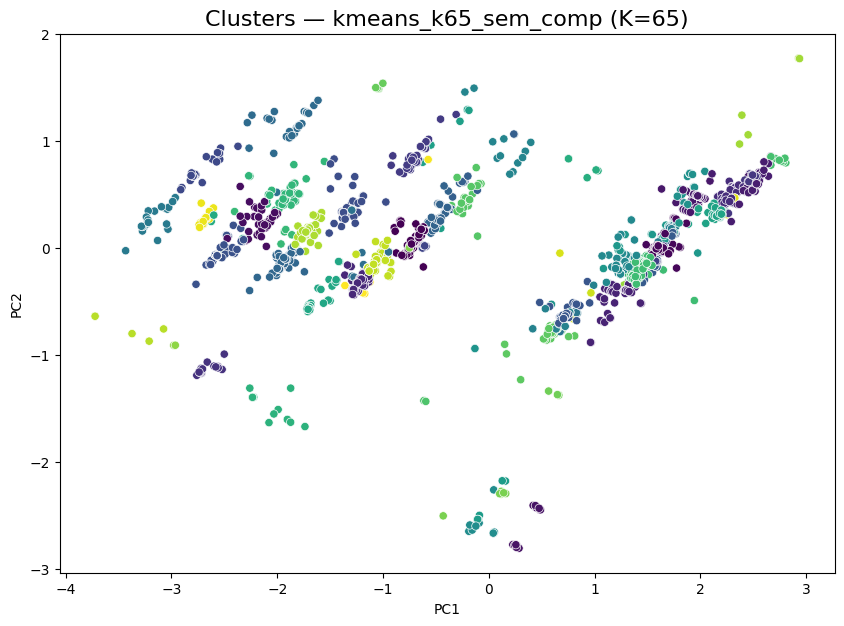

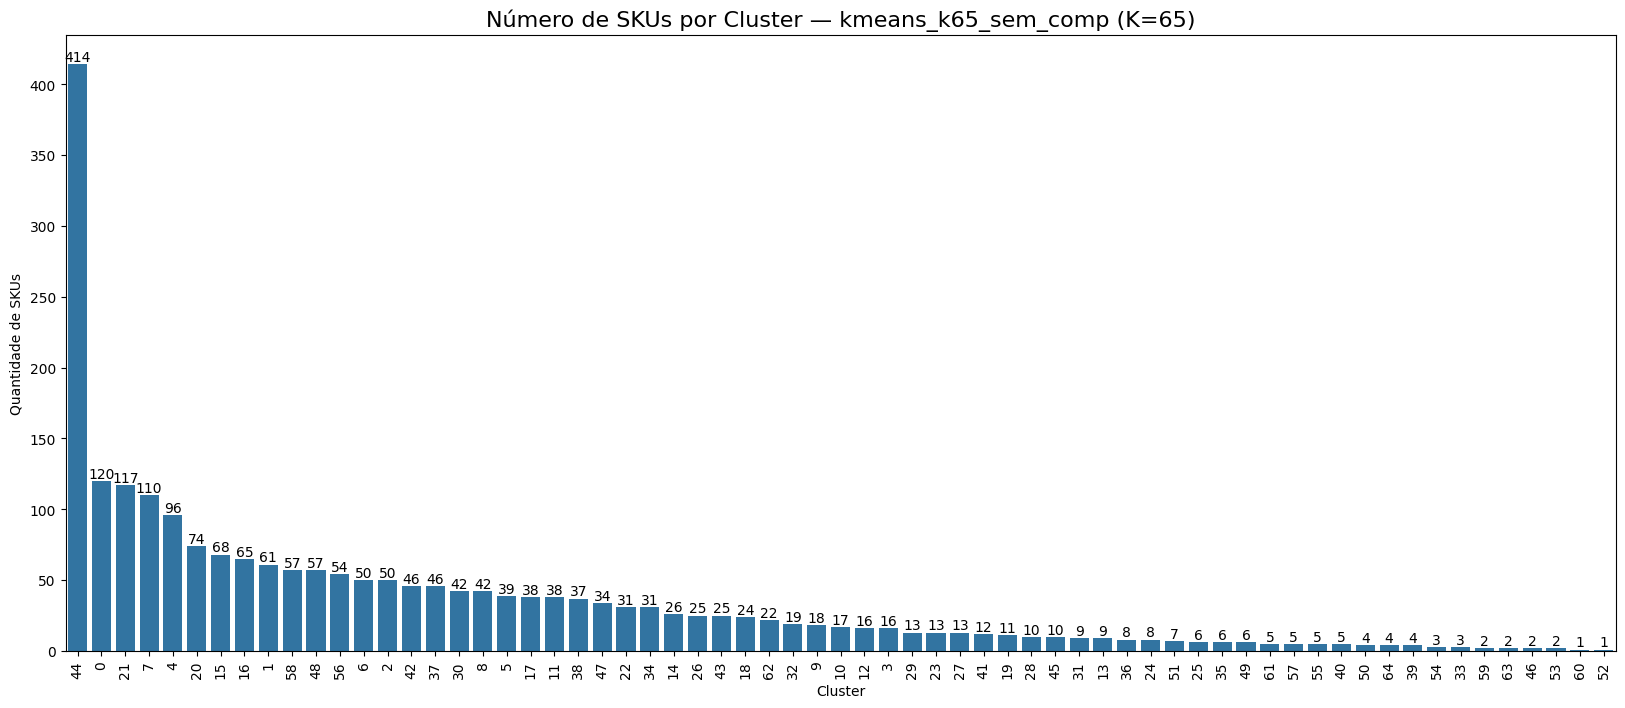

qt_altura_material                            \
                                  mean        std     min    max   
kmeans_k65_sem_comp                                                
0                           145.371667   3.133451  138.00  151.0   
1                           186.573770   3.073863  182.00  195.0   
2                           119.980000   4.871785  105.00  127.0   
3                            64.110000  14.709217   47.14   77.4   
4                           199.062500   2.827729  195.00  210.0   
...                                ...        ...     ...    ...   
60                          160.000000        NaN  160.00  160.0   
61                          202.000000   2.738613  200.00  205.0   
62                          108.500000   2.464027  105.00  115.0   
63                          167.000000   0.000000  167.00  167.0   
64                          121.250000   2.500000  120.00  125.0   

                    diametro_material                       qt_peso_bruto  \
                                 mean       std   min   max          mean   
kmeans_k65_sem_comp                                                         
0                           40.000000  0.000000  40.0  40.0    114.741592   
1                           50.000000  0.000000  50.0  50.0    231.005787   
2                           28.580000  2.914356  19.0  30.0     58.248480   
3                           50.000000  0.000000  50.0  50.0    278.368750   
4                           50.000000  0.000000  50.0  50.0    227.562146   
...                               ...       ...   ...   ...           ...   
60                          40.000000       NaN  40.0  40.0    287.490000   
61                          50.000000  0.000000  50.0  50.0    258.860000   
62                          24.727273  1.279204  19.0  25.0     35.883455   
63                          35.000000  0.000000  35.0  35.0    114.350000   
64                          40.000000  0.000000  40.0  40.0     84.880000   

                                                 
                           std     min      max  
kmeans_k65_sem_comp                              
0                     7.371018   90.00  141.000  
1                     8.787994  213.00  268.330  
2                     8.759042   43.00   87.000  
3                     4.642086  269.00  287.000  
4                    11.607659  181.26  276.066  
...                        ...     ...      ...  
60                         NaN  287.49  287.490  
61                   24.275049  231.90  279.600  
62                    1.517761   34.00   41.500  
63                    0.000000  114.35  114.350  
64                    9.696680   70.40   91.000  

[65 rows x 12 columns]


  Experimento: kmeans_k65_sem_comp
  - Pontuação de Silhueta:     0.5733 (Maior é melhor)
  - Índice de Davies-Bouldin:  0.5240 (Menor é melhor)
  ✓ Artefatos salvos em: ../models/kmeans_k65_sem_comp/


In [13]:
k = 65
nome = 'kmeans_k65_sem_comp'
dados = dados_para_modelo_sem_comp

modelo = KMeans(n_clusters=k, n_init=10, random_state=50)
inicio = time.time()
clusters = modelo.fit_predict(dados)
tempo = time.time() - inicio
print(f"Tempo de treinamento: {tempo:.4f}s")

score_sil = silhouette_score(dados, clusters)
score_db = davies_bouldin_score(dados, clusters)

salvar_artefatos(nome, modelo, dados, clusters, df_bis.copy(),
                 colunas_perfil_sem_comp, nome, k, 'K-Means',
                 score_sil, score_db)

---
## Resumo dos Experimentos

In [15]:
# Carregar métricas salvas de todos os experimentos
experimentos = [
    'hierar_k47_comp', 'hierar_k47_sem_comp', 'hierar_k65_comp', 'hierar_k65_sem_comp',
    'kmeans_k47_comp', 'kmeans_k47_sem_comp', 'kmeans_k65_comp', 'kmeans_k65_sem_comp'
]

resumo = []
for exp in experimentos:
    caminho = f'../models/{exp}/metricas.json'
    if os.path.exists(caminho):
        with open(caminho, 'r', encoding='utf-8') as f:
            m = json.load(f)
            resumo.append(m | {'experimento': exp})

df_resumo = pd.DataFrame(resumo)
df_resumo = df_resumo[['experimento', 'modelo', 'k', 'silhouette_score', 'davies_bouldin_score']]
if 'correlacao_cofenetica' in df_resumo.columns:
    df_resumo = df_resumo[['experimento', 'modelo', 'k', 'silhouette_score', 'davies_bouldin_score', 'correlacao_cofenetica']]


print("  RESUMO CONSOLIDADO DE TODOS OS EXPERIMENTOS")

display(df_resumo)

  RESUMO CONSOLIDADO DE TODOS OS EXPERIMENTOS


,experimento,modelo,k,silhouette_score,davies_bouldin_score
0,hierar_k47_comp,Hierárquico Ward,47,0.5582,0.8128
1,hierar_k47_sem_comp,Hierárquico Ward,47,0.5578,0.6119
2,hierar_k65_comp,Hierárquico Ward,65,0.5872,0.7268
3,hierar_k65_sem_comp,Hierárquico Ward,65,0.5746,0.5195
4,kmeans_k47_comp,K-Means,47,0.5386,0.7893
5,kmeans_k47_sem_comp,K-Means,47,0.5453,0.5688
6,kmeans_k65_comp,K-Means,65,0.5728,0.6218
7,kmeans_k65_sem_comp,K-Means,65,0.5733,0.5240
